In [1]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *
import itertools

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style

import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence,variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV

# Multiclass
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# calibration
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

# metrics

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import brier_score_loss

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error    
                            
# neural_network
from sklearn.neural_network import MLPClassifier,\
                                   MLPRegressor,\
                                   BernoulliRBM

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
import h5py
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
import visualkeras


from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
# layers
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Normalization,BatchNormalization
#CNN
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
#activations
from tensorflow.keras.activations import sigmoid
#utils
from tensorflow.keras.utils import to_categorical

#callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.callbacks import LambdaCallback
from tensorflow.keras.callbacks import TerminateOnNaN
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback

#preprocessing 
from tensorflow.keras.preprocessing import image


import sys
from copy import deepcopy

import kagglehub


In [2]:
def tableDispFormatt(yourString):
    fixLen = 90
    startLine = '==============================='
    textLen = len(yourString)
    endLineLen = fixLen - (len(startLine)+textLen)
    endLine = ''
    for i in np.arange(0,endLineLen,1):
        endLine += '='
    print(startLine,yourString,endLine)

In [3]:
def getRegressionEqn(regressionResdult):
    coeffs = regressionResdult.params
    # Build regression equation string
    equation = "Y = "
    equation += f"{coeffs['Intercept']:.3f}"
    for var in coeffs.index[1:]:
        if (coeffs[var]< 0):
            equation += f" - {coeffs[var]*-1:.3f} * {var}"
        else:
            equation += f" + {coeffs[var]:.3f} * {var}"
    print(equation)
    return equation


In [4]:
def dispAnalysisOfVariance(resResult):    
    tableDispFormatt('Analysis of Variance') 
    dfANOVA = pd.DataFrame({
                'Source Of Var':['Regression','Residual','Total'],
                'DegOfFreedom(DF)' :[resResult.df_model,resResult.df_resid,(resResult.df_model+resResult.df_resid)],
                'Sum Of Square(SS)':[resResult.ess,resResult.ssr,resResult.ess+resResult.ssr],                                
                'Mean Square(MS)':[resResult.mse_model,resResult.mse_resid,resResult.mse_model+resResult.mse_resid],
                'F': [resResult.fvalue,'---','---'],
                'FSig':[f.isf(q = 0.05, dfn = resResult.df_model,dfd = resResult.df_resid, loc=0, scale=1),'---','---'],
                'P':[resResult.f_pvalue,'---','---'],
                #'statement':[stetment,'---','---']
               })   
    print(dfANOVA.to_string())
    print('r-square: ',resResult.rsquared,'rSqr-adj',resResult.rsquared_adj,'rSqr-Predict')    
    #print(data.info(verbose=True))
    tableDispFormatt('Regression Equation') 
    getRegressionEqn(resResult)
    return dfANOVA

In [5]:
path = os.path.join(os.getcwd(), 'DataSet', 'Housing.csv')
df = pd.read_csv(path)
print(df.columns.values)

['price' 'area' 'bedrooms' 'bathrooms' 'stories' 'mainroad' 'guestroom'
 'basement' 'hotwaterheating' 'airconditioning' 'parking' 'prefarea'
 'furnishingstatus']


In [6]:
print(df.info())
print('area: ',df['area'].min(),df['area'].max(),' price : ',df['price'].min(),df['price'].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
area:  1650 16200  price :  1750000 13300000


In [7]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns

# --- One Hot Encoding ---
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_cat = encoder.fit_transform(df[categorical_cols])

# Convert encoded categorical features into DataFrame
encoded_df = pd.DataFrame(encoded_cat, columns=encoder.get_feature_names_out(categorical_cols))

# --- MinMax Scaling ---
scaler = MinMaxScaler(feature_range=(0, 1))  # default range is 0–1
scaled_num = scaler.fit_transform(df[numerical_cols])

scaled_df = pd.DataFrame(scaled_num, columns=numerical_cols)

# --- Combine back ---
final_df = pd.concat([scaled_df, encoded_df], axis=1)

#print(final_df.head())

In [8]:
scaled_num = scaler.fit_transform(df[numerical_cols])
scaled_df = pd.DataFrame(scaled_num, columns=numerical_cols)

# Check if any negative values exist
has_negative = (scaled_df < 0).any().any()

if has_negative:
    print("Negative values found in scaled numerical features.")
else:
    print("No negative values found. All features are within [0,1].")

# Optionally, show min/max per column
print(scaled_df.min().min(), scaled_df.max().max())


No negative values found. All features are within [0,1].
0.0 1.0000000000000002


In [9]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns

# --- One Hot Encoding ---
encoder = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' avoids dummy trap
encoded_cat = encoder.fit_transform(df[categorical_cols])

# Convert encoded categorical features into DataFrame
encoded_df = pd.DataFrame(encoded_cat, columns=encoder.get_feature_names_out(categorical_cols))

# --- Standard Scaling ---
scaler = StandardScaler()
scaled_num = scaler.fit_transform(df[numerical_cols])

scaled_df = pd.DataFrame(scaled_num, columns=numerical_cols)

# --- Combine back ---
df = pd.concat([scaled_df, encoded_df], axis=1)

print(df.columns)


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


In [10]:
print('area: ',df['area'].min(),df['area'].max(),' price : ',df['price'].min(),df['price'].max())

area:  -1.6145297379755097 5.096263187737839  price :  -1.6143267488861697 4.566365125868969


In [11]:
scaled_num = scaler.fit_transform(df[numerical_cols])
scaled_df = pd.DataFrame(scaled_num, columns=numerical_cols)

# Check if any negative values exist
has_negative = (scaled_df < 0).any().any()

if has_negative:
    print("Negative values found in scaled numerical features.")
else:
    print("No negative values found. All features are within [0,1].")

# Optionally, show min/max per column
print(scaled_df.min().min(), scaled_df.max().max())

Negative values found in scaled numerical features.
-2.665003779665438 5.405808633904847


Now we can see after apply StandardScaler we got -ve values and in MinMaxScaler we didn't get any -ve value.

#### Qus: So which one is the correct approach?

StandardScaler $=$ $X' = \frac{X-\mu }{\sigma }$

MinMaxScaler $=$ $X'=\frac{X-X_{\min }}{X_{\max }-X_{\min }}$

In StandardScaler Any value below the mean becomes negative, and any value above the mean becomes positive.This is expected behavior and not a problem for most ML algorithms. StandardScaler produces unbounded values, including negatives

House Prices dataset, StandardScaler is perfectly fine — housing prices, square footage, etc. don’t need to stay positive after scaling because models only care about relative relationships.


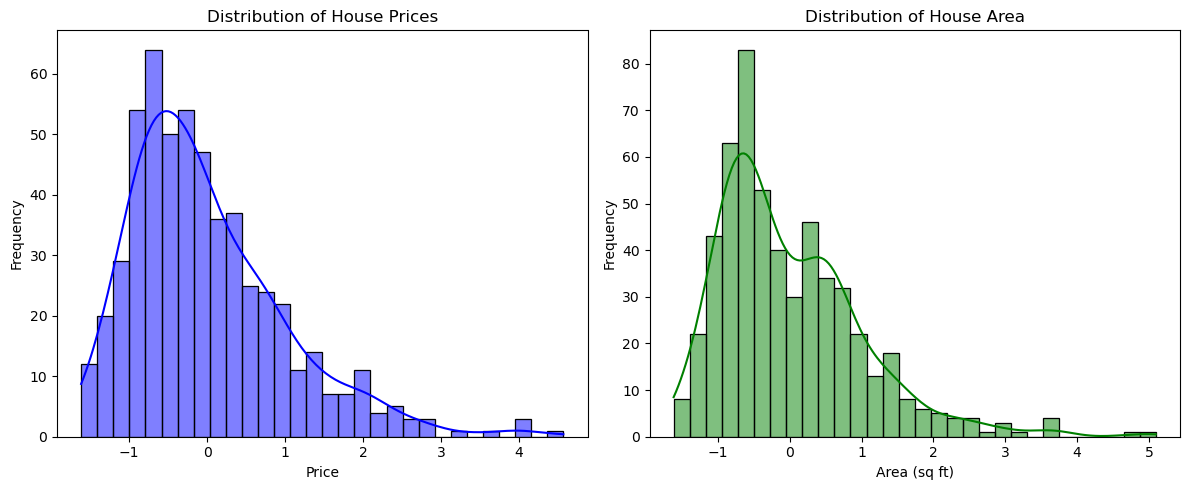

In [12]:
# --- Histogram for Price ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['price'], bins=30, kde=True, color='blue')
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

# --- Histogram for Area ---
plt.subplot(1,2,2)
sns.histplot(df['area'], bins=30, kde=True, color='green')
plt.title("Distribution of House Area")
plt.xlabel("Area (sq ft)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


We apply one-hot encoding to transform categorical variables into numerical variables. This process is called one-hot encoding. The resulting indicator variables are often referred to as dummy variables.

#### Q1: Explain mathematically why indicator (dummy) variables are required in statistical and machine learning models.

Now take 3 variable from housing Dataset 
- price, area     ==> Numerical variable
- mainroad        ==> Categorical variable

now assume Let $y$ == price; $x_1$ == area, $x_2$ == mainroad

So regressions models equations

$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon $  ---- (i)

Now we know mainroad i.e. $x_2$ have only two params i.e. YES and NO. Let assume YES = 1 & NO = 0

Now we can write equations (i)  when $x_2$ = YES = 1 in this situations equations (i) become

- $y = \beta_0 + \beta_1 x_1 + \beta_2*1 + \varepsilon$
- $y = \beta_0 + \beta_1 x_1 + \beta_2 + \varepsilon$
- $y = (\beta_0 + \beta_2) + \beta_1 x_1 + \varepsilon$  ----(ii)

when $x_2$ = NO = 0 in this situations equations (i) become
- $y = \beta_0 + \beta_1 x_1 + \beta_2*0 + \varepsilon$
- $y = \beta_0 + \beta_1 x_1 + \varepsilon$   ---- (iii)

Equations (ii) and (iii) have the same slope i.e. $\beta_2$ and different intercept i.e. equations (ii) intercept = $(\beta_0 + \beta_2)$ and equations (iii) have intercept = $\beta_0$.

SO equations (ii) and (iii) have common slope and different intercept. Hack!!! conditions of parallel line. This situations called two-line solutions — the regression model fits two parallel lines, one for each category 

Since both straight lines are assumed to have the same slope, it makes sense to combine the data from both mainroad types to produce a single estimate of this common parameter. This approach also gives one estimate of the common error variance σ² and more residual degrees of freedom than would result from fitting two separate regression lines.

Furthermore, **Multicollinearity risk** If you create dummy variables for all categories, you get perfect collinearity (the "dummy variable trap"). That’s why we drop one category as the baseline. **Interpretation challenge** The regression line splits into multiple lines depending on categories, which complicates interpretation if you don’t understand dummy coding.

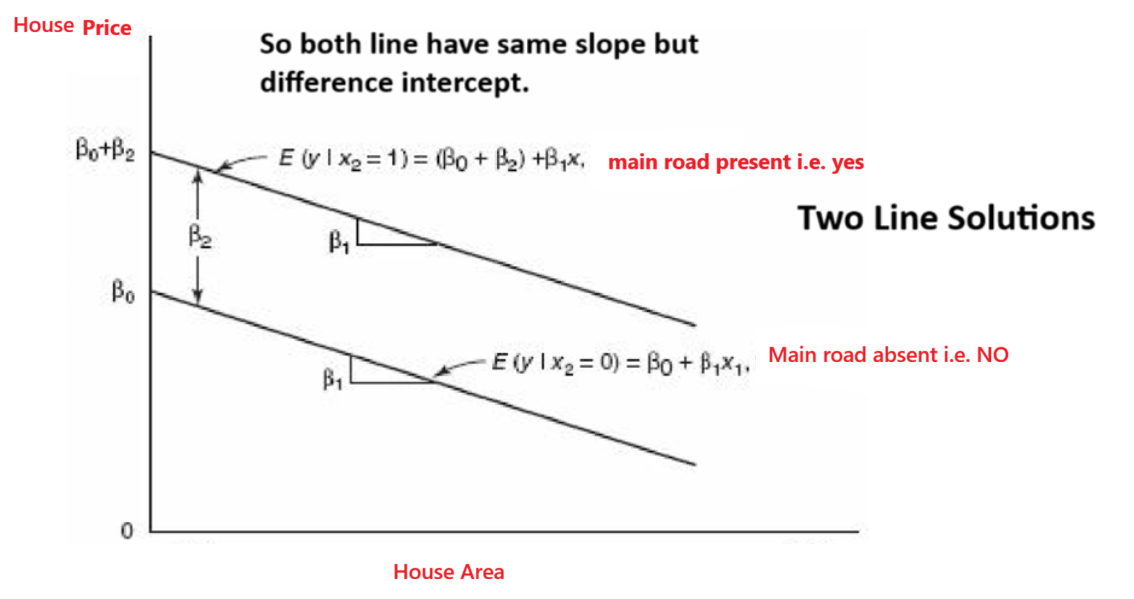

Single-model approach is preferred because the analyst has only one final equation to work with instead of two, a much simpler practical result.

Qus: How we can achieve Single-model approach ?

Now we need to use one hot encoding tecgnique. This will modify the equations (i)

$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1 x_2 + \varepsilon$  ---- (iv) 

Now first considered main road face not available with house i.e. $x_2 = 0$ So equations (iv) become

- $y = \beta_0 + \beta_1 x_1 + \beta_2*0 + \beta_3 x_1*0 + \varepsilon$
- $y = \beta_0 + \beta_1 x_1 + \varepsilon$   ----- (v)

considered main road face available with house i.e. $x_2 = 1$ So equations (iv) become
- $y = \beta_0 + \beta_1 x_1 + \beta_2*1 + \beta_3 x_1*1 + \varepsilon$
- $y = (\beta_0 + \beta_2) + \beta_1 x_1 + \beta_3 x_1*1 + \varepsilon$
- $y = (\beta_0 + \beta_2) + (\beta_1 + \beta_3) x_1 + \varepsilon$   --- (vi)

A miracle has happened in the equations (vi). 

You can see slope of equations (v) $\beta_1$ and slope of equations (vi) $(\beta_1 + \beta_3)$.Slope are different and intercept of equations (v) $\beta_0$ and intercept of equations (vi) $(\beta_0 + \beta_2)$.

So this called Single-model approach


In [13]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

In [14]:
# Extra code, Create map value only.
numerical_vars = ['AR', 'BD', 'BT', 'ST', 'PAR']
indicator_vars = ['MRD', 'GR', 'BS', 'HW', 'AC', 'PAR', 'FSS', 'FSU']
# Generate new list of interaction names
interaction_terms = [f"{num}*{ind}" for num in numerical_vars for ind in indicator_vars]

# Print result
# print(interaction_terms)
map_value = {
	'price': 'PR',
	'area': 'AR',
	'bedrooms': 'BD',
	'bathrooms': 'BT',
	'stories': 'ST',
	'parking': 'PARK',
 
	'mainroad_yes': 'MRD',
	'guestroom_yes': 'GR',
	'basement_yes': 'BS',
	'hotwaterheating_yes': 'HW',
	'airconditioning_yes': 'AC',
	'prefarea_yes': 'PAREA',
	'furnishingstatus_semi-furnished': 'FSS',
	'furnishingstatus_unfurnished': 'FSU',
}
df.columns = ['PR', 'AR', 'BD', 'BT', 'ST', 'PARK', 'MRD', 'GR', 'BS', 'HW', 'AC', 'PAREA', 'FSS', 'FSU']
print(df.columns)
# Convert dictionary to DataFrame
dfMapped = pd.DataFrame(list(map_value.items()), columns=["Attribute", "Code"])

# Print table
print(dfMapped.to_string(index=False))


Index(['PR', 'AR', 'BD', 'BT', 'ST', 'PARK', 'MRD', 'GR', 'BS', 'HW', 'AC',
       'PAREA', 'FSS', 'FSU'],
      dtype='object')
                      Attribute  Code
                          price    PR
                           area    AR
                       bedrooms    BD
                      bathrooms    BT
                        stories    ST
                        parking  PARK
                   mainroad_yes   MRD
                  guestroom_yes    GR
                   basement_yes    BS
            hotwaterheating_yes    HW
            airconditioning_yes    AC
                   prefarea_yes PAREA
furnishingstatus_semi-furnished   FSS
   furnishingstatus_unfurnished   FSU


Two line solutions regression equation:

$Y=\beta _0+\beta _1\cdot \mathrm{AR}+\beta _2\cdot \mathrm{BD}+\beta _3\cdot \mathrm{BT}+\beta _4\cdot \mathrm{ST}+\beta _5\cdot \mathrm{PARK}+\gamma _1\cdot \mathrm{MRD}+\gamma _2\cdot \mathrm{GR}+\gamma _3\cdot \mathrm{BS}+\gamma _4\cdot \mathrm{HW}+\gamma _5\cdot \mathrm{AC}+\gamma _6\cdot \mathrm{PAREA} +\gamma _7\cdot \mathrm{FSS}+\gamma _8\cdot \mathrm{FSU}+\epsilon$ 

Single Line Solutions Regressions equations Models:

$\begin{aligned}Y&=\beta _0+\beta _1\cdot AR+\beta _2\cdot BD+\beta _3\cdot BT+\beta _4\cdot ST+\beta _5\cdot PARK\\ &+\gamma _1\cdot (AR\cdot MRD)+\gamma _2\cdot (AR\cdot GR)+\gamma _3\cdot (AR\cdot BS)+\gamma _4\cdot (AR\cdot HW)+\gamma _5\cdot (AR\cdot AC)+\gamma _6\cdot (AR\cdot PAREA)+\gamma _7\cdot (AR\cdot FSS)+\gamma _8\cdot (AR\cdot FSU)\\ &+\gamma _9\cdot (BD\cdot MRD)+\gamma _{10}\cdot (BD\cdot GR)+\gamma _{11}\cdot (BD\cdot BS)+\gamma _{12}\cdot (BD\cdot HW)+\gamma _{13}\cdot (BD\cdot AC)+\gamma _{14}\cdot (BD\cdot PAREA)+\gamma _{15}\cdot (BD\cdot FSS)+\gamma _{16}\cdot (BD\cdot FSU)\\ &+\gamma _{17}\cdot (BT\cdot MRD)+\gamma _{18}\cdot (BT\cdot GR)+\gamma _{19}\cdot (BT\cdot BS)+\gamma _{20}\cdot (BT\cdot HW)+\gamma _{21}\cdot (BT\cdot AC)+\gamma _{22}\cdot (BT\cdot PAREA)+\gamma _{23}\cdot (BT\cdot FSS)+\gamma _{24}\cdot (BT\cdot FSU)\\ &+\gamma _{25}\cdot (ST\cdot MRD)+\gamma _{26}\cdot (ST\cdot GR)+\gamma _{27}\cdot (ST\cdot BS)+\gamma _{28}\cdot (ST\cdot HW)+\gamma _{29}\cdot (ST\cdot AC)+\gamma _{30}\cdot (ST\cdot PAREA)+\gamma _{31}\cdot (ST\cdot FSS)+\gamma _{32}\cdot (ST\cdot FSU)\\ &+\gamma _{33}\cdot (PARK\cdot MRD)+\gamma _{34}\cdot (PARK\cdot GR)+\gamma _{35}\cdot (PARK\cdot BS)+\gamma _{36}\cdot (PARK\cdot HW)+\gamma _{37}\cdot (PARK\cdot AC)+\gamma _{38}\cdot (PARK\cdot PAREA)+\gamma _{39}\cdot (PARK\cdot FSS)+\gamma _{40}\cdot (PARK\cdot FSU)\\ &+\epsilon \end{aligned}$




#### Model 1: Two-Line Solutions:

**Interpretation**: Each categorical variable shifts the intercept (parallel regression lines).
Simple, easy to interpret, fewer parameters.Assumes the slope of numerical variables is the same across categories. That means, for example, the effect of Area on Price is identical whether the house is on the main road or not.**Oversimplifies relationships if categories actually change slopes**

#### Model 2: Single-Line Solutions (with interactions):

Equation form:

$Y=\beta _0+\beta _1AR+\beta _2BD+\beta _3BT+\beta _4ST+\beta _5PAR+\sum \gamma _{ij}(NumVar_i\cdot Indicator_j)+\epsilon$ 

**Interpretation** Allows slopes of numerical variables to vary depending on categories (interaction terms).
More flexible, captures richer relationships (e.g., area may increase price more strongly in urban houses than rural).Many parameters,** risk of overfitting** if dataset is small.**Harder to interpret, requires careful regularization or feature selection**.



#### Single line solutions models:

In [15]:
y, X = dmatrices('PR ~ AR + BD + BT + ST + PAR + AR*MRD + AR*GR + AR*BS + AR*HW + AR*AC + AR*PAR + AR*FSS + AR*FSU + BD*MRD + BD*GR + BD*BS + BD*HW + BD*AC + BD*PAR + BD*FSS + BD*FSU + BT*MRD + BT*GR + BT*BS + BT*HW + BT*AC + BT*PAR + BT*FSS + BT*FSU + ST*MRD + ST*GR + ST*BS + ST*HW + ST*AC + ST*PAR + ST*FSS + ST*FSU + PAR*MRD + PAR*GR + PAR*BS + PAR*HW + PAR*AC + PAR*PAR + PAR*FSS + PAR*FSU'
, data=df, return_type='dataframe')
print(y.shape, X.shape)

PatsyError: Error evaluating factor: NameError: name 'PAR' is not defined
    PR ~ AR + BD + BT + ST + PAR + AR*MRD + AR*GR + AR*BS + AR*HW + AR*AC + AR*PAR + AR*FSS + AR*FSU + BD*MRD + BD*GR + BD*BS + BD*HW + BD*AC + BD*PAR + BD*FSS + BD*FSU + BT*MRD + BT*GR + BT*BS + BT*HW + BT*AC + BT*PAR + BT*FSS + BT*FSU + ST*MRD + ST*GR + ST*BS + ST*HW + ST*AC + ST*PAR + ST*FSS + ST*FSU + PAR*MRD + PAR*GR + PAR*BS + PAR*HW + PAR*AC + PAR*PAR + PAR*FSS + PAR*FSU
                             ^^^

#### Two Line solutions models

In [ ]:
y_two,X_two = dmatrices('PR ~ AR + BD + BT + ST + PAR + MRD + GR + BS + HW + AC + PAR + FSS + FSU',data=df, return_type='dataframe')
print(y_two.shape, X_two.shape)

(545, 1) (545, 14)


In [ ]:
models_single_line = sm.OLS(y, X)                # Describe model
res_single_line = models_single_line.fit()       # Fit model
print(res_single_line.summary())                             # Summarize model

                            OLS Regression Results                            
Dep. Variable:                     PR   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     22.67
Date:                Sun, 18 Jan 2026   Prob (F-statistic):          2.94e-108
Time:                        15:58:44   Log-Likelihood:                -397.64
No. Observations:                 545   AIC:                             923.3
Df Residuals:                     481   BIC:                             1199.
Df Model:                          63                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6773      0.139     -4.869      0.0

Brief discussions about models summery:

No. Observations: 545 totals number of samples

Degree of freedom (DoF):
	- DoF of Models: (number of Regressor variable + const term - 1) 
          why -1. You can see total 63 regressor variable are used and plus one const term. So we need to remove
          constant term from degree of freedom.
        - DoF of residuals: n- k -1 where n = number of sample, k = number of regressor or dependent variable
          545 - 63 - 1 = 481 = Totals numbers of variable required to calculate predicted values $y$
          


In [ ]:
dispAnalysisOfVariance(res_single_line)

=============================== Analysis of Variance =======================================
  Source Of Var  DegOfFreedom(DF)  Sum Of Square(SS)  Mean Square(MS)          F      FSig    P
0    Regression              63.0         407.701912         6.471459  22.671632  1.338894  0.0
1      Residual             481.0         137.298088         0.285443        ---       ---  ---
2         Total             544.0         545.000000         6.756902        ---       ---  ---
r-square:  0.7480769034043541 rSqr-adj 0.7150807389853817 rSqr-Predict
=============================== Regression Equation ========================================
Y = -0.677 + 0.134 * AR + 0.196 * BD - 0.095 * BT + 0.090 * ST - 0.042 * PAR[0] - 0.411 * PAR[1] + 0.434 * MRD + 0.104 * AR:MRD + 0.301 * GR - 0.310 * AR:GR + 0.180 * BS + 0.142 * AR:BS + 0.328 * HW - 0.021 * AR:HW + 0.423 * AC + 0.065 * AR:AC - 0.066 * AR:PAR[0] + 0.059 * AR:PAR[1] - 0.008 * FSS - 0.010 * AR:FSS - 0.216 * FSU - 0.000 * AR:FSU - 0.034 * BD:

,Source Of Var,DegOfFreedom(DF),Sum Of Square(SS),Mean Square(MS),F,FSig,P
0,Regression,63.0,407.701912,6.471459,22.671632,1.338894,0.0
1,Residual,481.0,137.298088,0.285443,---,---,---
2,Total,544.0,545.000000,6.756902,---,---,---


In [ ]:
models_two_line = sm.OLS(y_two, X_two)                # Describe model
res_two_line = models_two_line.fit()       # Fit model
print(res_two_line.summary())    

                            OLS Regression Results                            
Dep. Variable:                     PR   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Sun, 18 Jan 2026   Prob (F-statistic):          9.07e-123
Time:                        15:58:44   Log-Likelihood:                -461.29
No. Observations:                 545   AIC:                             950.6
Df Residuals:                     531   BIC:                             1011.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4546      0.089     -5.111      0.0

In [ ]:
dispAnalysisOfVariance(res_two_line)

=============================== Analysis of Variance =======================================
  Source Of Var  DegOfFreedom(DF)  Sum Of Square(SS)  Mean Square(MS)          F      FSig    P
0    Regression              13.0         371.582007        28.583231  87.520883  1.738607  0.0
1      Residual             531.0         173.417993         0.326588        ---       ---  ---
2         Total             544.0         545.000000        28.909819        ---       ---  ---
r-square:  0.681801848554014 rSqr-adj 0.6740116866542065 rSqr-Predict
=============================== Regression Equation ========================================
Y = -0.455 + 0.283 * AR + 0.045 * BD + 0.265 * BT + 0.209 * ST + 0.128 * PAR[0] + 0.349 * PAR[1] + 0.225 * MRD + 0.161 * GR + 0.187 * BS + 0.458 * HW + 0.463 * AC - 0.025 * FSS - 0.220 * FSU


,Source Of Var,DegOfFreedom(DF),Sum Of Square(SS),Mean Square(MS),F,FSig,P
0,Regression,13.0,371.582007,28.583231,87.520883,1.738607,0.0
1,Residual,531.0,173.417993,0.326588,---,---,---
2,Total,544.0,545.000000,28.909819,---,---,---


In [ ]:

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.to_string())


       feature        VIF
0    Intercept  36.940735
1           AR  34.130319
2           BD  18.841649
3           BT  18.920855
4           ST  39.302941
5       PAR[0]  37.074637
6       PAR[1]  64.917355
7          MRD   3.679488
8       AR:MRD  25.981659
9           GR   2.240670
10       AR:GR   2.179481
11          BS   2.113785
12       AR:BS   2.870166
13          HW   1.658477
14       AR:HW   1.569172
15          AC   1.861857
16       AR:AC   2.510551
17   AR:PAR[0]   1.664420
18   AR:PAR[1]   2.176692
19         FSS   2.381732
20      AR:FSS   3.213561
21         FSU   2.545464
22      AR:FSU   3.025622
23      BD:MRD  11.052761
24       BD:GR   2.466076
25       BD:BS   2.768283
26       BD:HW   2.382497
27       BD:AC   2.327660
28   BD:PAR[0]   1.728247
29   BD:PAR[1]   1.993042
30      BD:FSS   3.315627
31      BD:FSU   3.479253
32      BT:MRD  11.594932
33       BT:GR   2.004647
34       BT:BS   2.788784
35       BT:HW   2.545155
36       BT:AC   2.914580
37   BT:PAR[

In [ ]:
vif_data_two_line = pd.DataFrame()
vif_data_two_line["feature"] = X_two.columns
vif_data_two_line["VIF"] = [variance_inflation_factor(X_two.values, i) for i in range(X_two.shape[1])]
print(vif_data_two_line.to_string())

      feature        VIF
0   Intercept  13.201413
1          AR   1.325250
2          BD   1.369477
3          BT   1.286621
4          ST   1.478055
5      PAR[0]   1.212837
6      PAR[1]   1.149196
7         MRD   1.172728
8          GR   1.212838
9          BS   1.323050
10         HW   1.041506
11         AC   1.211840
12        FSS   1.578233
13        FSU   1.674139
